# Task 2/3/4: Model Training - Baseline CNN

## Overview

This notebook trains the **CustomCNN baseline** model for fresh vs rotten fruit/vegetable classification.

**Objectives:**
1. Train the baseline CustomCNN from scratch
2. Record training/validation accuracy and loss
3. Establish baseline performance for comparison
4. Save the best model checkpoint

**Model:** CustomCNN (3 conv blocks, 1.7M params)  
**Dataset:** 28 classes (14 produce types × 2 states)  
**Training:** ~26K images, Validation: ~6.5K images

---

## Contents

1. Setup and Configuration
2. Load Data (using train.py)
3. Create Model
4. Training Loop
5. Results Visualization
6. Model Checkpoint Saving

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Add repo root to path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "config.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from task2_3_4_cv_quality.src.model import create_model, print_model_summary
from task2_3_4_cv_quality.src.train import create_dataloaders

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

Using device: cpu


## 1. Load Data with WeightedRandomSampler

Load the training, validation, and test dataloaders created in `train.py`.

**Key points:**
- Training loader uses WeightedRandomSampler for class balance
- Validation/test loaders use standard sequential loading
- Batch size: 32

In [2]:
print("Loading dataloaders...")
bundle = create_dataloaders(verbose=True)

train_loader = bundle.train_loader
val_loader = bundle.val_loader
test_loader = bundle.test_loader
classes = bundle.classes

print(f"\n✓ Data loaded successfully!")
print(f"  Training batches:   {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches:       {len(test_loader)}")

Loading dataloaders...
Class balance (threshold = 0.70 of largest class):
  Apple__Rotten           2331  (100.0%)
  Banana__Rotten          2249  ( 96.5%)
  Apple__Healthy          1899  ( 81.5%)
  Mango__Rotten           1788  ( 76.7%)
  Orange__Rotten          1756  ( 75.3%)
  Orange__Healthy         1666  ( 71.5%)
  Banana__Healthy         1606  ( 68.9%)  FLAGGED
  Mango__Healthy          1464  ( 62.8%)  FLAGGED
  Strawberry__Healthy     1289  ( 55.3%)  FLAGGED
  Strawberry__Rotten      1286  ( 55.2%)  FLAGGED
  Bellpepper__Healthy      505  ( 21.7%)  FLAGGED
  Tomato__Rotten           496  ( 21.3%)  FLAGGED
  Potato__Healthy          486  ( 20.8%)  FLAGGED
  Carrot__Healthy          482  ( 20.7%)  FLAGGED
  Cucumber__Healthy        482  ( 20.7%)  FLAGGED
  Tomato__Healthy          480  ( 20.6%)  FLAGGED
  Bellpepper__Rotten       477  ( 20.5%)  FLAGGED
  Cucumber__Rotten         465  ( 19.9%)  FLAGGED
  Potato__Rotten           464  ( 19.9%)  FLAGGED
  Carrot__Rotten           447

## 2. Create Baseline CustomCNN Model

**Architecture:**
- 3 convolutional blocks (Conv → ReLU → MaxPool)
- AdaptiveAvgPool (28×28 → 7×7)
- 2 fully connected layers with Dropout (0.5)
- **Total parameters:** ~1.7M

This is our **baseline** - we'll compare transfer learning models against this later.

In [3]:
# Create model
model = create_model(
    num_classes=len(classes),
    dropout_rate=0.5,
    device=device
)

# Print summary
print_model_summary(model, verbose=True)

# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (removed verbose parameter)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print("\n✓ Model, optimizer, and scheduler created!")

MODEL SUMMARY
Architecture: CustomCNN
Classes:      28
Dropout:      0.50
Total params:     1,706,332
Trainable params: 1,706,332
Non-trainable:    0

Layer Details:
--------------------------------------------------------------------------------

features:
  0: Conv2d                      896 params
  1: ReLU                          0 params
  2: MaxPool2d                     0 params
  3: Conv2d                   18,496 params
  4: ReLU                          0 params
  5: MaxPool2d                     0 params
  6: Conv2d                   73,856 params
  7: ReLU                          0 params
  8: MaxPool2d                     0 params
avgpool                       0 params

classifier:
  0: Linear                1,605,888 params
  1: ReLU                          0 params
  2: Dropout                       0 params
  3: Linear                    7,196 params
--------------------------------------------------------------------------------

✓ Model, optimizer, and scheduler cr

## 3. Training Loop

**Configuration:**
- Epochs: 20 (adjust as needed)
- Optimizer: Adam (lr=0.001)
- Loss: CrossEntropyLoss
- Scheduler: ReduceLROnPlateau (patience=3)
- Early stopping: Best validation loss

**Metrics tracked:**
- Training loss & accuracy
- Validation loss & accuracy

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


print("✓ Training functions defined!")

✓ Training functions defined!


In [6]:
# SMOKE TEST: Train 1 epoch to verify everything works
num_epochs = 1
best_val_loss = float('inf')
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("=" * 80)
print("SMOKE TEST: TRAINING 1 EPOCH")
print("=" * 80)

# Create overall progress bar for epochs
epoch_pbar = tqdm(range(num_epochs), desc="Overall Progress", position=0, leave=True)

for epoch in epoch_pbar:
    epoch_pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Update epoch progress bar with metrics
    epoch_pbar.set_postfix({
        'train_loss': f'{train_loss:.4f}',
        'train_acc': f'{train_acc:.2f}%',
        'val_loss': f'{val_loss:.4f}',
        'val_acc': f'{val_acc:.2f}%'
    })
    
    # Print detailed epoch summary
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{num_epochs} Summary:")
    print(f"{'='*80}")
    print(f"  📊 Training   → Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"  📊 Validation → Loss: {val_loss:.4f} | Accuracy: {val_acc:.2f}%")
    
    # Save model (smoke test)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Create models directory if it doesn't exist
        models_dir = REPO_ROOT / 'task2_3_4_cv_quality' / 'models'
        models_dir.mkdir(parents=True, exist_ok=True)
        
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, models_dir / 'baseline_cnn_smoke_test.pth')
        print(f"  💾 Saved smoke test model (val_loss: {val_loss:.4f})")
    print(f"{'='*80}\n")

# Close epoch progress bar
epoch_pbar.close()

print("\n" + "=" * 80)
print("🎉 SMOKE TEST COMPLETE!")
print("=" * 80)
print(f"📈 Final Train Accuracy: {train_acc:.2f}%")
print(f"📈 Final Val Accuracy:   {val_acc:.2f}%")
print(f"📉 Best Val Loss:        {best_val_loss:.4f}")
print("=" * 80)
print("\n✅ If you see this, everything is working correctly!")
print("💡 Change num_epochs to 20 for full training.")

SMOKE TEST: TRAINING 1 EPOCH


Overall Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Training:   0%|          | 0/733 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]


Epoch 1/1 Summary:
  📊 Training   → Loss: 1.3883 | Accuracy: 58.81%
  📊 Validation → Loss: 0.9640 | Accuracy: 71.24%
  💾 Saved smoke test model (val_loss: 0.9640)


🎉 SMOKE TEST COMPLETE!
📈 Final Train Accuracy: 58.81%
📈 Final Val Accuracy:   71.24%
📉 Best Val Loss:        0.9640

✅ If you see this, everything is working correctly!
💡 Change num_epochs to 20 for full training.


In [7]:
# Training configuration
num_epochs = 20
best_val_loss = float('inf')
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("=" * 80)
print("STARTING TRAINING")
print("=" * 80)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 80)
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, REPO_ROOT / 'task2_3_4_cv_quality' / 'models' / 'baseline_cnn_best.pth')
        print(f"  ✓ Saved new best model (val_loss: {val_loss:.4f})")

print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)
print(f"Best Validation Loss: {best_val_loss:.4f}")

STARTING TRAINING

Epoch 1/20
--------------------------------------------------------------------------------


Training:   0%|          | 0/733 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]


Epoch 1 Summary:
  Train Loss: 1.0401 | Train Acc: 68.59%
  Val   Loss: 0.7978 | Val   Acc: 76.51%
  ✓ Saved new best model (val_loss: 0.7978)

Epoch 2/20
--------------------------------------------------------------------------------


Training:   0%|          | 0/733 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/184 [00:00<?, ?it/s]


Epoch 19 Summary:
  Train Loss: 0.2387 | Train Acc: 92.46%
  Val   Loss: 0.2930 | Val   Acc: 92.45%

Epoch 20/20
--------------------------------------------------------------------------------


Training:   0%|          | 0/733 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]


Epoch 20 Summary:
  Train Loss: 0.2336 | Train Acc: 92.41%
  Val   Loss: 0.3339 | Val   Acc: 92.05%

TRAINING COMPLETE!
Best Validation Loss: 0.2919


## 4. Training Results Visualization

Plot training and validation curves to assess:
- Model convergence
- Overfitting (gap between train/val)
- Learning rate effectiveness

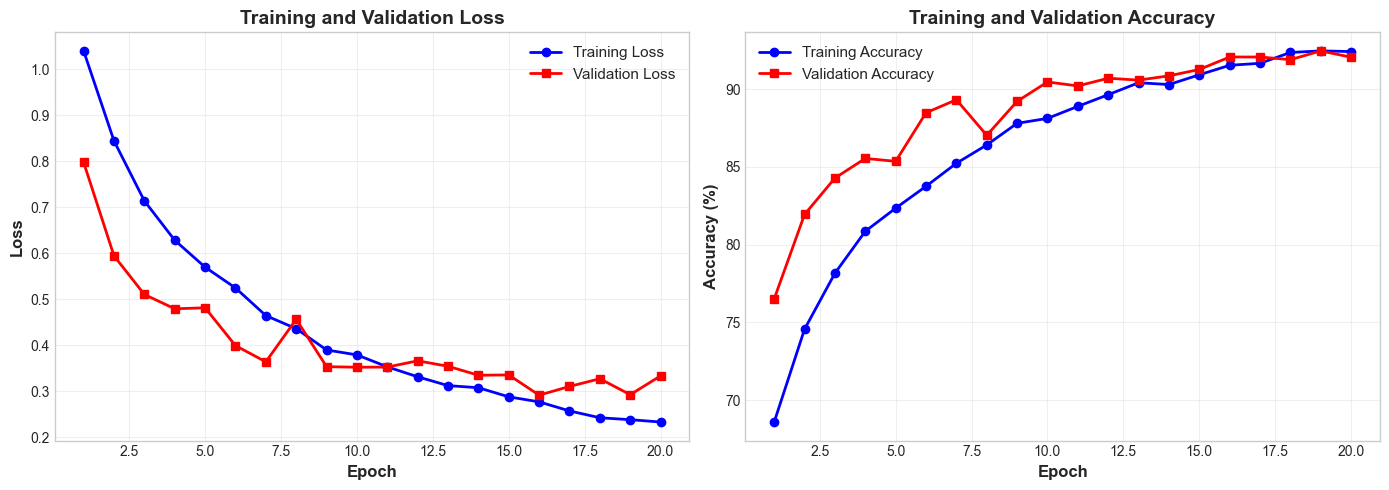

Final Metrics:
  Train Accuracy: 92.41%
  Val   Accuracy: 92.05%
  Best Val Loss:  0.2919


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss plot
ax1.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs, history['train_acc'], 'b-o', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, history['val_acc'], 'r-s', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("Final Metrics:")
print(f"  Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Val   Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"  Best Val Loss:  {best_val_loss:.4f}")

## 5. Next Steps

✅ **Baseline Performance Recorded**

**What's Next:**
1. Evaluate on test set (notebook 04_evaluation.ipynb)
2. Implement transfer learning models (ResNet, EfficientNet)
3. Compare baseline vs transfer learning
4. Implement XAI (Grad-CAM) for interpretability

**Expected Baseline Performance:**
- ~40-60% accuracy (28-class problem is challenging!)
- Transfer learning should significantly outperform this